# 2D Molecular Dynamics with Velocity Verlet

This notebook implements a **2D molecular dynamics (MD)** simulation using the **Velocity Verlet** integration method.

We model particles in a 2D periodic square box with Lennard-Jones interactions:
$$U(r)=4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12}-\left(\frac{\sigma}{r}\right)^6\right].$$

Velocity Verlet update equations in vector form:
$$\mathbf{r}_{i}(t+\Delta t)=\mathbf{r}_i(t)+\mathbf{v}_i(t)\Delta t+\frac{1}{2}\mathbf{a}_i(t)\Delta t^2,$$
$$\mathbf{v}_i(t+\Delta t)=\mathbf{v}_i(t)+\frac{1}{2}\left[\mathbf{a}_i(t)+\mathbf{a}_i(t+\Delta t)\right]\Delta t.$$

In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
# ------------------------------
# Simulation parameters
# ------------------------------
N = 36                 # number of particles (must be a perfect square)
m = 1.0                # particle mass
epsilon = 1.0          # Lennard-Jones energy scale
sigma = 1.0            # Lennard-Jones length scale
L = 10.0               # box length (2D periodic square box)
rc = 2.5 * sigma       # cutoff radius
dt = 0.003             # timestep
runtime = 150.0        # total simulation time
n_steps = int(runtime / dt) # total integration steps
sample_every = 2000      # store every k steps for plotting

k_B = 1.0              # Boltzmann constant in reduced units
T_target = 2.0         # Target temperature

rng = np.random.default_rng(42)

In [54]:
# ------------------------------
# Initial conditions
# ------------------------------
# Create a 2D lattice
n_dim = int(np.sqrt(N))
if n_dim * n_dim != N:
    raise ValueError("N must be a perfect square for lattice initialization.")

spacing = L / n_dim
x_1d = np.linspace(0.5 * spacing, L - 0.5 * spacing, n_dim)
xx, yy = np.meshgrid(x_1d, x_1d)
r = np.zeros((N, 2))
r[:, 0] = xx.flatten()
r[:, 1] = yy.flatten()

# Add small random jitter
r += 0.05 * sigma * rng.normal(size=(N, 2))
r = np.mod(r, L)

# Maxwell-Boltzmann initial velocities in 2D
sigma_v = np.sqrt(k_B * T_target / m)
v = rng.normal(loc=0.0, scale=sigma_v, size=(N, 2))
v -= np.mean(v, axis=0)  # remove center-of-mass drift

In [55]:
def minimum_image_2d(dr, box_length):
    """Apply 2D minimum-image convention for periodic boundaries."""
    return dr - box_length * np.rint(dr / box_length)

def forces_and_potential_2d(r, L, epsilon, sigma, rc):
    """Compute pair forces and potential energy in 2D with LJ + cutoff."""
    N = r.shape[0]
    f = np.zeros_like(r)
    U = 0.0
    rc2 = rc * rc

    # Shift potential so U(rc)=0 for continuity
    inv_rc2 = 1.0 / (rc * rc)
    inv_rc6 = (sigma * sigma * inv_rc2) ** 3
    U_shift = 4.0 * epsilon * (inv_rc6 * inv_rc6 - inv_rc6)

    for i in range(N - 1):
        for j in range(i + 1, N):
            dr = minimum_image_2d(r[j] - r[i], L)
            r2 = np.sum(dr * dr)

            if r2 < rc2 and r2 > 1e-14:
                inv_r2 = 1.0 / r2
                s2_over_r2 = (sigma * sigma) * inv_r2
                s6_over_r6 = s2_over_r2 ** 3
                s12_over_r12 = s6_over_r6 ** 2

                # Force magnitude divided by r
                f_scalar = 24.0 * epsilon * (2.0 * s12_over_r12 - s6_over_r6) * inv_r2
                fij = f_scalar * dr

                f[i] -= fij
                f[j] += fij

                U += 4.0 * epsilon * (s12_over_r12 - s6_over_r6) - U_shift

    return f, U

In [56]:
# ------------------------------
# Velocity Verlet integration
# ------------------------------
f, U = forces_and_potential_2d(r, L, epsilon, sigma, rc)
a = f / m

times = []
r_samples = []
KE_hist, PE_hist, TE_hist = [], [], []
T_hist = []

for step in range(n_steps):
    # 1) Update positions
    r = r + v * dt + 0.5 * a * dt * dt
    r = np.mod(r, L)

    # 2) Compute new acceleration from new positions
    f_new, U = forces_and_potential_2d(r, L, epsilon, sigma, rc)
    a_new = f_new / m

    # 3) Update velocities with average acceleration
    v = v + 0.5 * (a + a_new) * dt

    # 4) Move to next acceleration
    a = a_new

    # Diagnostics
    KE = 0.5 * m * np.sum(v * v)
    PE = U
    TE = KE + PE
    
    # Instantaneous temperature in 2D
    T_inst = KE / (N * k_B)

    KE_hist.append(KE)
    PE_hist.append(PE)
    TE_hist.append(TE)
    T_hist.append(T_inst)

    if step % sample_every == 0:
        times.append(step * dt)
        r_samples.append(np.copy(r))

times = np.array(times)
r_samples = np.array(r_samples)

print(f"Completed {n_steps} steps.")
print(f"Initial total energy: {TE_hist[0]:.6f}")
print(f"Final total energy:   {TE_hist[-1]:.6f}")
print(f"Relative drift:       {(TE_hist[-1]-TE_hist[0])/(abs(TE_hist[0])+1e-12):.3e}")
print(f"Mean temperature:     {np.mean(T_hist):.3f}")

Completed 50000 steps.
Initial total energy: 48.580520
Final total energy:   48.596431
Relative drift:       3.275e-04
Mean temperature:     2.066


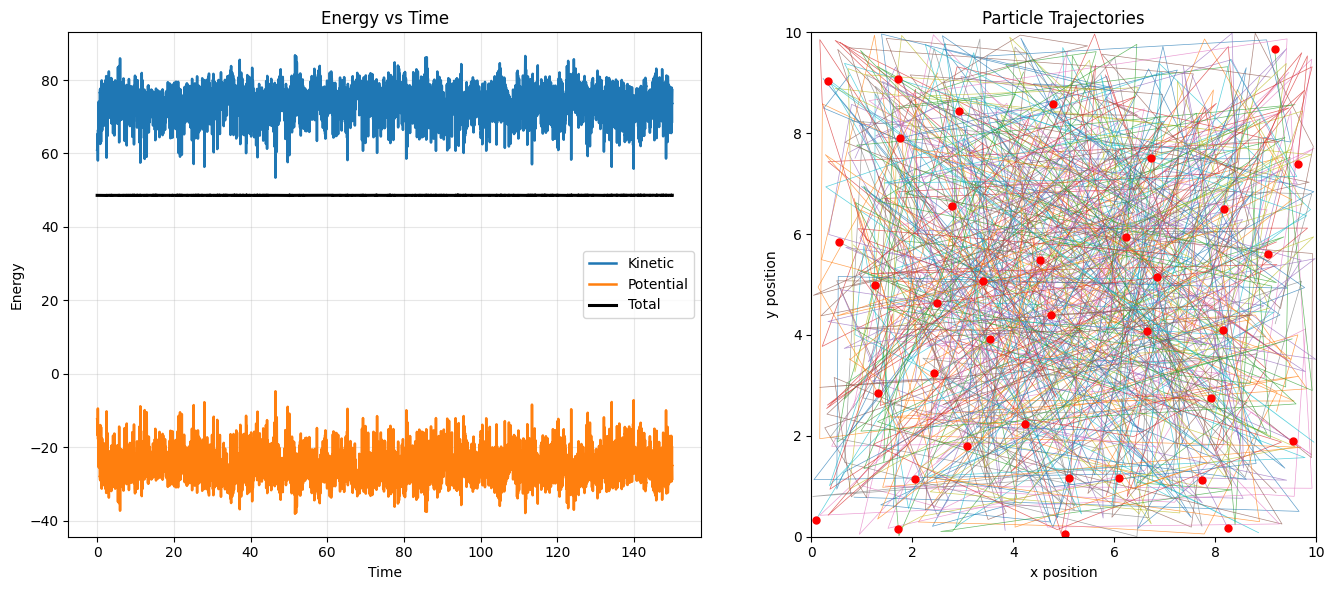

In [57]:
# ------------------------------
# Plots
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Energy plot
t_full = np.arange(n_steps) * dt
axes[0].plot(t_full, KE_hist, label="Kinetic", lw=1.8)
axes[0].plot(t_full, PE_hist, label="Potential", lw=1.8)
axes[0].plot(t_full, TE_hist, label="Total", lw=2.2, color="black")
axes[0].set_title("Energy vs Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Energy")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Trajectory plot (final frame)
axes[1].set_aspect('equal')
axes[1].set_title("Particle Trajectories")
axes[1].set_xlabel("x position")
axes[1].set_ylabel("y position")
axes[1].set_xlim(0, L)
axes[1].set_ylim(0, L)

# Plot trajectories over time
for i in range(N):
    axes[1].plot(r_samples[:, i, 0], r_samples[:, i, 1], lw=0.5, alpha=0.7)

# Plot final positions
axes[1].plot(r_samples[-1, :, 0], r_samples[-1, :, 1], 'o', markersize=5, color='red')

plt.tight_layout()
plt.show()

### JC: the relative drift is quite high, so i might mess with the time step as it is quite low.

In [58]:
# ------------------------------
# Velocity Verlet integration
# ------------------------------
f, U = forces_and_potential_2d(r, L, epsilon, sigma, rc)
a = f / m
n_steps = 100000
dt = 0.0001

times = []
r_samples = []
KE_hist, PE_hist, TE_hist = [], [], []

for step in range(n_steps):
    # 1) Update positions
    r = r + v * dt + 0.5 * a * dt * dt
    r = np.mod(r, L)

    # 2) Compute new acceleration from new positions
    f_new, U = forces_and_potential_2d(r, L, epsilon, sigma, rc)
    a_new = f_new / m

    # 3) Update velocities with average acceleration
    v = v + 0.5 * (a + a_new) * dt

    # 4) Move to next acceleration
    a = a_new

    # Diagnostics
    KE = 0.5 * m * np.sum(v * v)
    PE = U
    TE = KE + PE

    KE_hist.append(KE)
    PE_hist.append(PE)
    TE_hist.append(TE)

    if step % sample_every == 0:
        times.append(step * dt)
        r_samples.append(np.copy(r))

times = np.array(times)
r_samples = np.array(r_samples)

print(f"Completed {n_steps} steps.")
print(f"Initial total energy: {TE_hist[0]:.6f}")
print(f"Final total energy:   {TE_hist[-1]:.6f}")
print(f"Relative drift:       {(TE_hist[-1]-TE_hist[0])/(abs(TE_hist[0])+1e-12):.3e}")

Completed 100000 steps.
Initial total energy: 48.596431
Final total energy:   48.596533
Relative drift:       2.118e-06


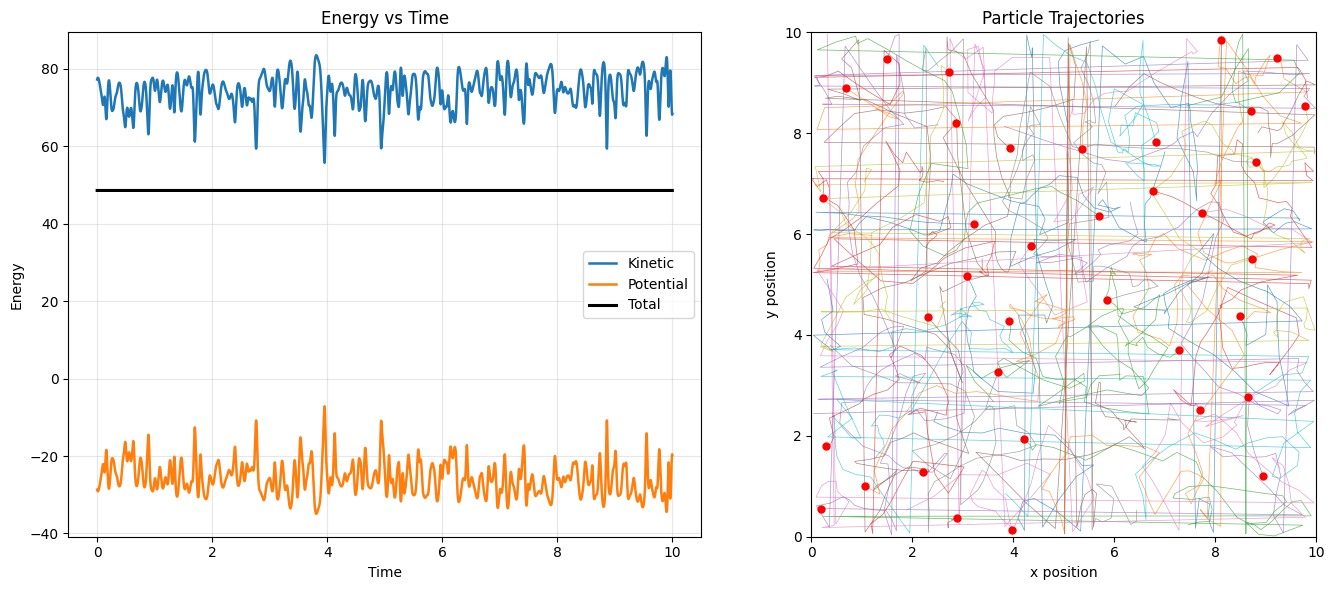

In [59]:
# ------------------------------
# Plots
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Energy plot
t_full = np.arange(n_steps) * dt
axes[0].plot(t_full, KE_hist, label="Kinetic", lw=1.8)
axes[0].plot(t_full, PE_hist, label="Potential", lw=1.8)
axes[0].plot(t_full, TE_hist, label="Total", lw=2.2, color="black")
axes[0].set_title("Energy vs Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Energy")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Trajectory plot (final frame)
axes[1].set_aspect('equal')
axes[1].set_title("Particle Trajectories")
axes[1].set_xlabel("x position")
axes[1].set_ylabel("y position")
axes[1].set_xlim(0, L)
axes[1].set_ylim(0, L)

# Plot trajectories over time
for i in range(N):
    axes[1].plot(r_samples[:, i, 0], r_samples[:, i, 1], lw=0.5, alpha=0.7)

# Plot final positions
axes[1].plot(r_samples[-1, :, 0], r_samples[-1, :, 1], 'o', markersize=5, color='red')

plt.tight_layout()
plt.show()

### JC: Id say this is a reasonable drift considering the energy level its at in comparison. Not to mention the system is bounded (meaning negative potential). The energy vs time graphs are much cleaner. But then again this is only for 5 seconds because of the amount of dt.

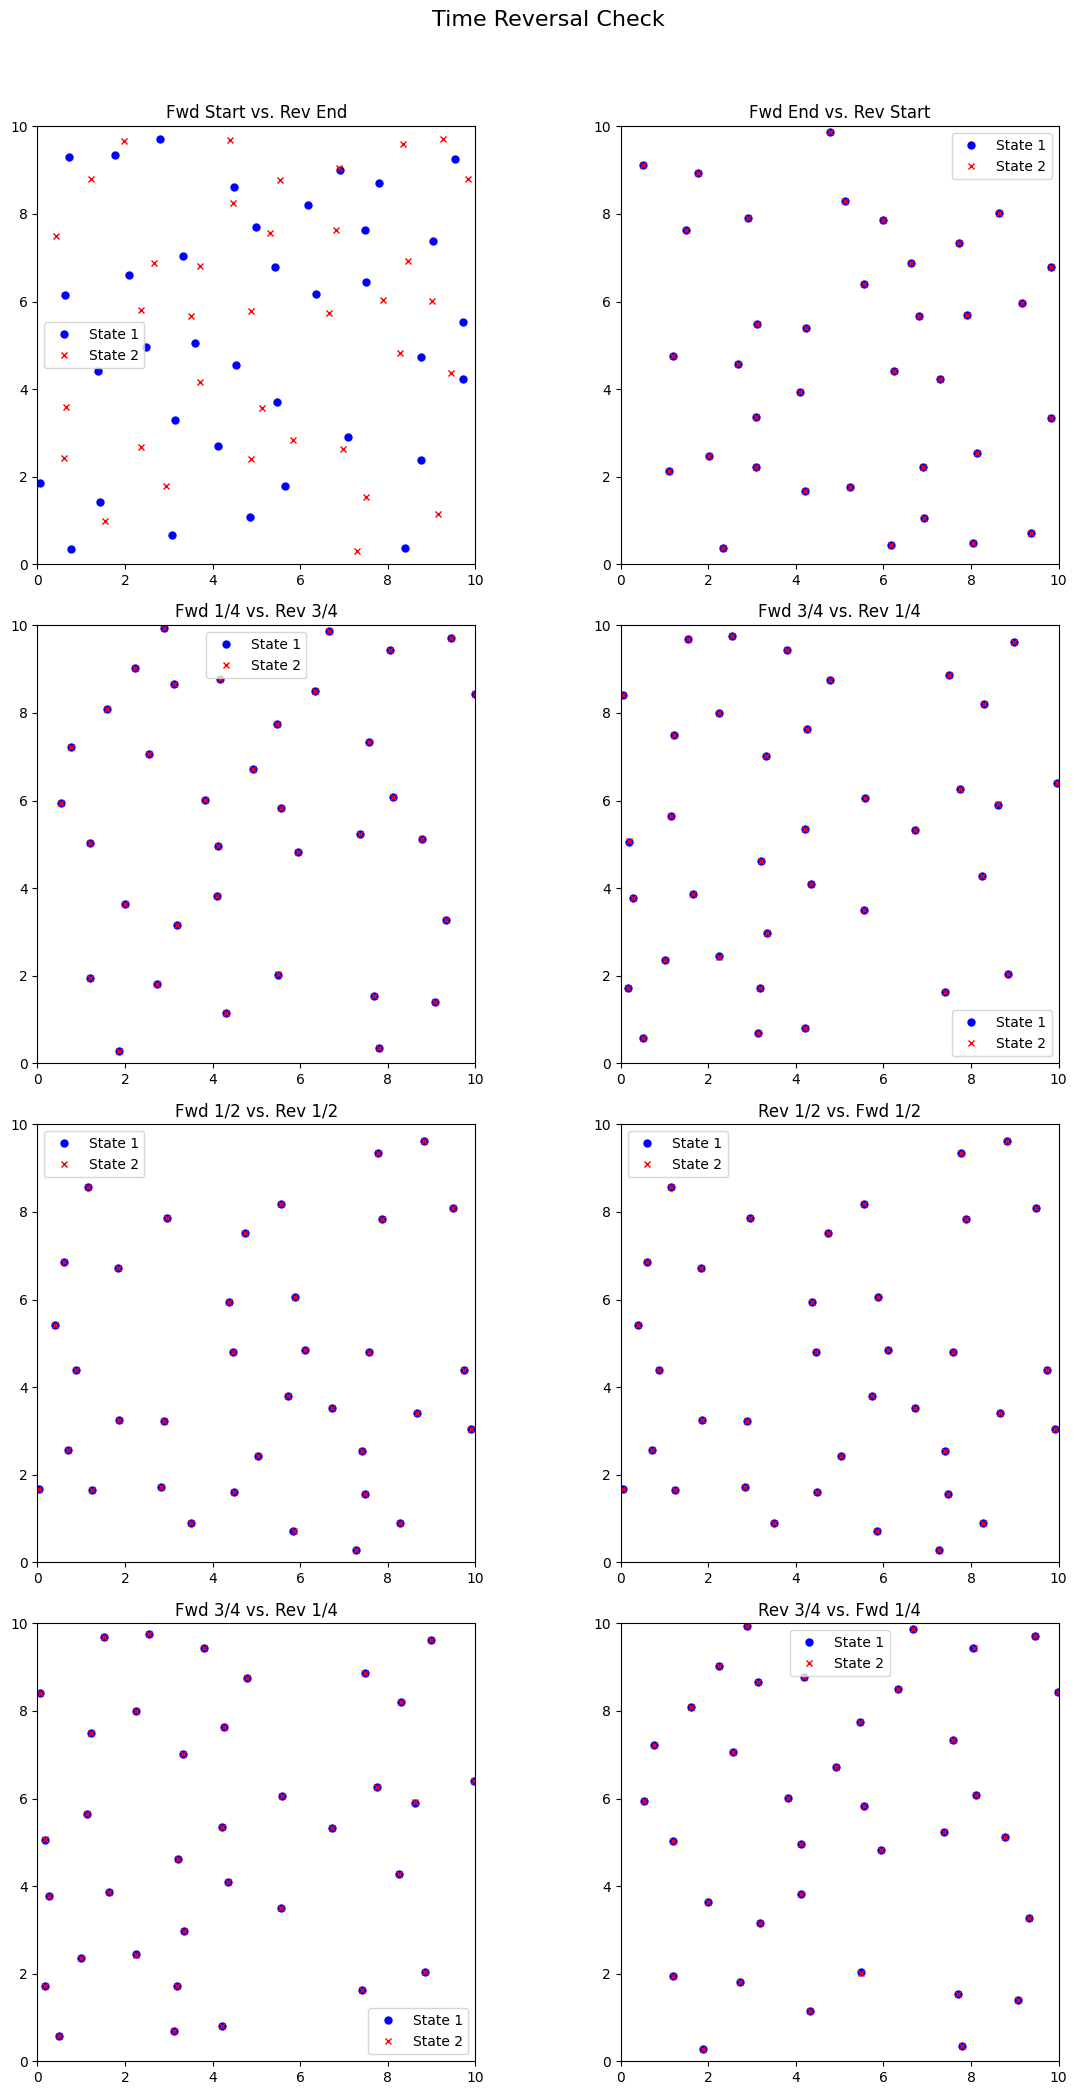

In [61]:
# ------------------------------
# Time Reversal Check
# ------------------------------

# --- 1. Run simulation forward and store states ---
r_fwd = np.copy(r)
v_fwd = np.copy(v)

f_fwd, _ = forces_and_potential_2d(r_fwd, L, epsilon, sigma, rc)
a_fwd = f_fwd / m

# States to store
checkpoints = {
    'start': None,
    'q1': None,
    'half': None,
    'q3': None,
    'end': None
}
checkpoint_steps = {
    'start': 0,
    'q1': n_steps // 4,
    'half': n_steps // 2,
    'q3': 3 * n_steps // 4,
    'end': n_steps - 1
}

checkpoints['start'] = np.copy(r_fwd)

for step in range(n_steps):
    r_fwd = np.mod(r_fwd + v_fwd * dt + 0.5 * a_fwd * dt * dt, L)
    f_new_fwd, _ = forces_and_potential_2d(r_fwd, L, epsilon, sigma, rc)
    a_new_fwd = f_new_fwd / m
    v_fwd = v_fwd + 0.5 * (a_fwd + a_new_fwd) * dt
    a_fwd = a_new_fwd

    if step == checkpoint_steps['q1']:
        checkpoints['q1'] = np.copy(r_fwd)
    elif step == checkpoint_steps['half']:
        checkpoints['half'] = np.copy(r_fwd)
    elif step == checkpoint_steps['q3']:
        checkpoints['q3'] = np.copy(r_fwd)

checkpoints['end'] = np.copy(r_fwd)

# --- 2. Run simulation backward ---
r_rev = np.copy(checkpoints['end'])
v_rev = -np.copy(v_fwd) # Reverse velocities

f_rev, _ = forces_and_potential_2d(r_rev, L, epsilon, sigma, rc)
a_rev = f_rev / m

# States to store for reverse run
rev_checkpoints = {
    'start': None,
    'q1': None,
    'half': None,
    'q3': None,
    'end': None
}

rev_checkpoints['start'] = np.copy(r_rev)

for step in range(n_steps):
    r_rev = np.mod(r_rev + v_rev * dt + 0.5 * a_rev * dt * dt, L)
    f_new_rev, _ = forces_and_potential_2d(r_rev, L, epsilon, sigma, rc)
    a_new_rev = f_new_rev / m
    v_rev = v_rev + 0.5 * (a_rev + a_new_rev) * dt
    a_rev = a_new_rev

    if step == checkpoint_steps['q1']:
        rev_checkpoints['q1'] = np.copy(r_rev)
    elif step == checkpoint_steps['half']:
        rev_checkpoints['half'] = np.copy(r_rev)
    elif step == checkpoint_steps['q3']:
        rev_checkpoints['q3'] = np.copy(r_rev)

rev_checkpoints['end'] = np.copy(r_rev)


# --- 3. Plotting ---
fig, axes = plt.subplots(4, 2, figsize=(12, 22))
fig.suptitle('Time Reversal Check', fontsize=16, y=0.95)

plot_map = [
    (axes[0, 0], checkpoints['start'], rev_checkpoints['end'], 'Fwd Start vs. Rev End'),
    (axes[0, 1], checkpoints['end'], rev_checkpoints['start'], 'Fwd End vs. Rev Start'),
    (axes[1, 0], checkpoints['q1'], rev_checkpoints['q3'], 'Fwd 1/4 vs. Rev 3/4'),
    (axes[1, 1], checkpoints['q3'], rev_checkpoints['q1'], 'Fwd 3/4 vs. Rev 1/4'),
    (axes[2, 0], checkpoints['half'], rev_checkpoints['half'], 'Fwd 1/2 vs. Rev 1/2'),
    (axes[2, 1], rev_checkpoints['half'], checkpoints['half'], 'Rev 1/2 vs. Fwd 1/2'),
    (axes[3, 0], checkpoints['q3'], rev_checkpoints['q1'], 'Fwd 3/4 vs. Rev 1/4'),
    (axes[3, 1], rev_checkpoints['q3'], checkpoints['q1'], 'Rev 3/4 vs. Fwd 1/4')
]

for ax, r1, r2, title in plot_map:
    ax.set_title(title)
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect('equal')
    ax.plot(r1[:, 0], r1[:, 1], 'bo', label='State 1', markersize=5)
    ax.plot(r2[:, 0], r2[:, 1], 'rx', label='State 2', markersize=5)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### JC: This is weird, why is everything besides the forward start and reverse end the same. THis is very peculiar I should ask it numerically how far each are from state 1 and state 2. Time to go back to ye ole reliable, increase step size and increase runtime

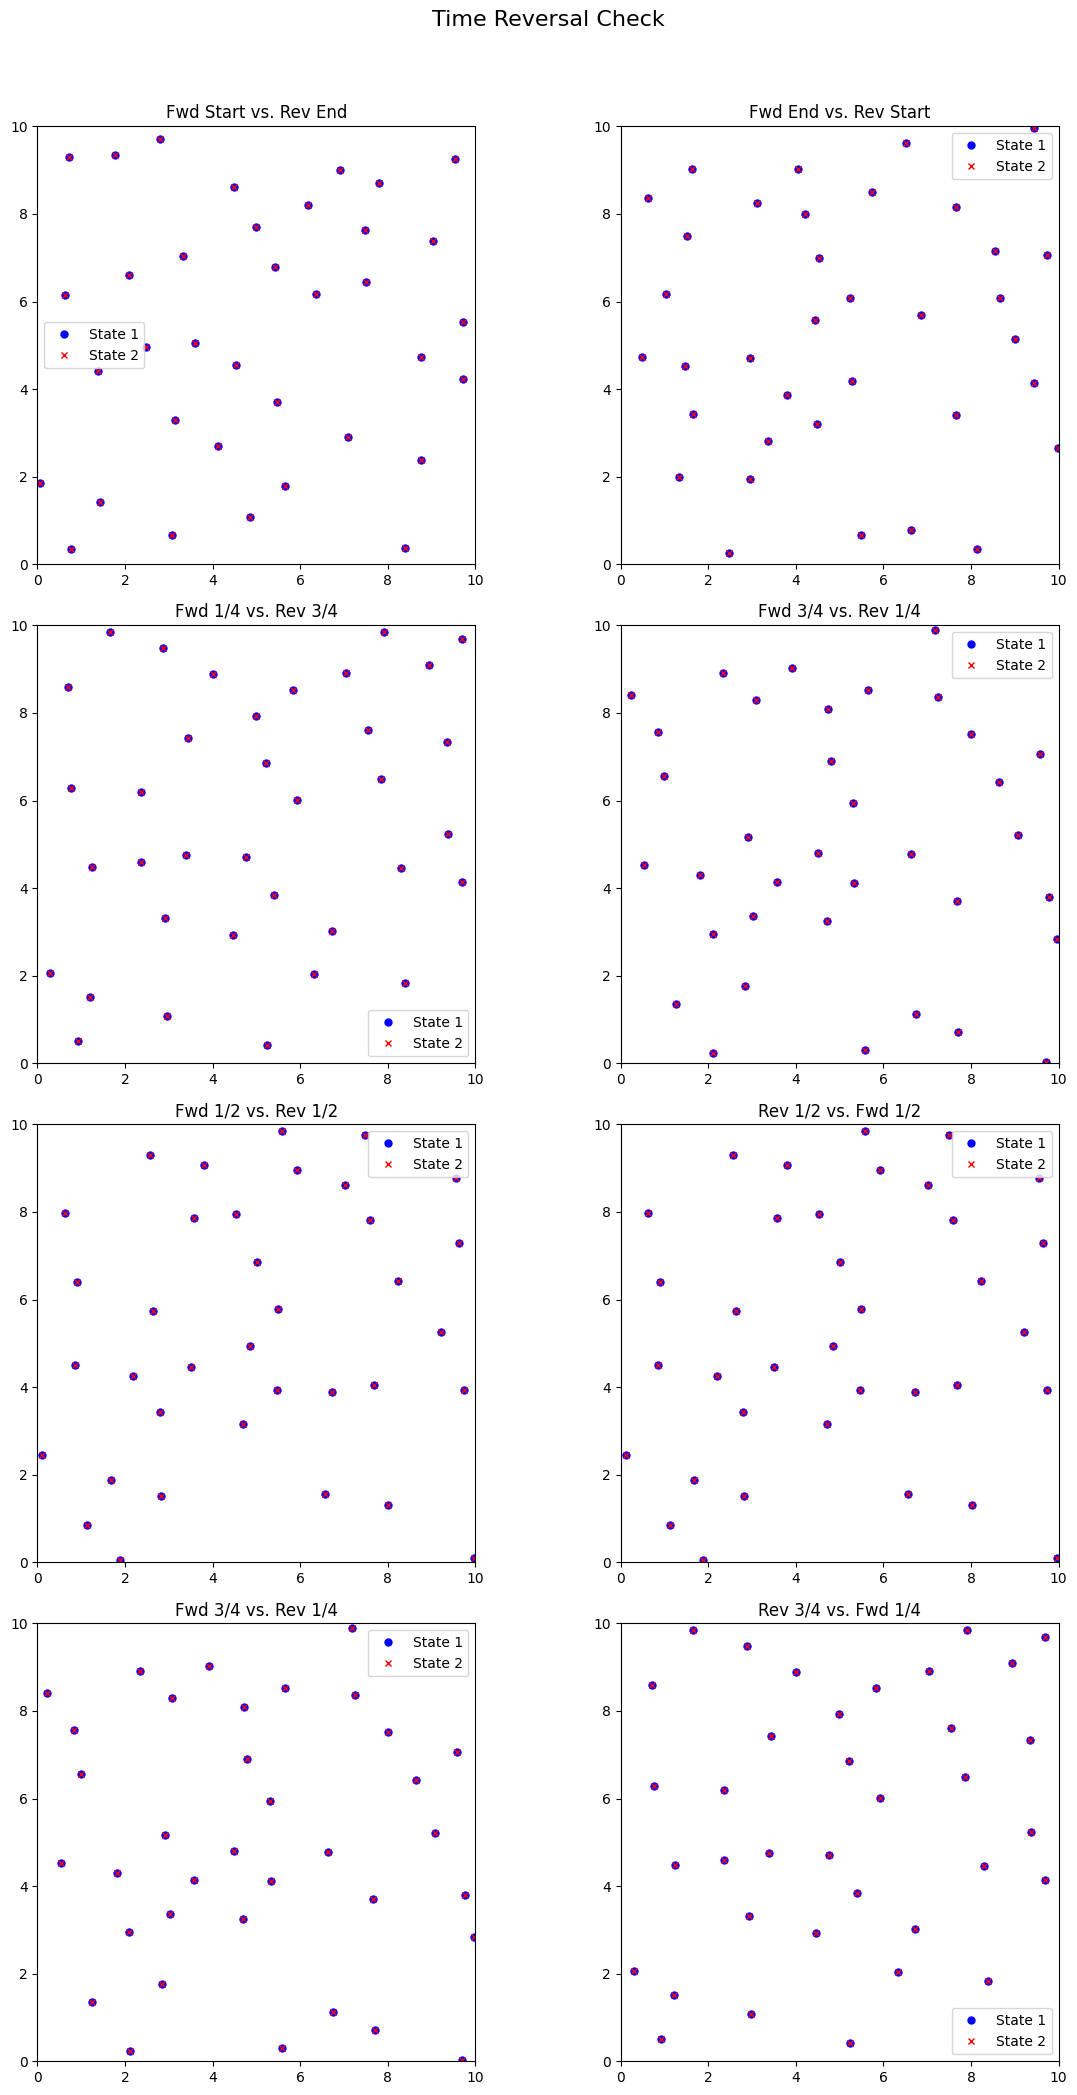

In [64]:
# ------------------------------
# Time Reversal Check
# ------------------------------

dt = 0.00001
runtime = 1
n_steps = int(runtime / dt)
# --- 1. Run simulation forward and store states ---
r_fwd = np.copy(r)
v_fwd = np.copy(v)

f_fwd, _ = forces_and_potential_2d(r_fwd, L, epsilon, sigma, rc)
a_fwd = f_fwd / m

# States to store
checkpoints = {
    'start': None,
    'q1': None,
    'half': None,
    'q3': None,
    'end': None
}
checkpoint_steps = {
    'start': 0,
    'q1': n_steps // 4,
    'half': n_steps // 2,
    'q3': 3 * n_steps // 4,
    'end': n_steps - 1
}

checkpoints['start'] = np.copy(r_fwd)

for step in range(n_steps):
    r_fwd = np.mod(r_fwd + v_fwd * dt + 0.5 * a_fwd * dt * dt, L)
    f_new_fwd, _ = forces_and_potential_2d(r_fwd, L, epsilon, sigma, rc)
    a_new_fwd = f_new_fwd / m
    v_fwd = v_fwd + 0.5 * (a_fwd + a_new_fwd) * dt
    a_fwd = a_new_fwd

    if step == checkpoint_steps['q1']:
        checkpoints['q1'] = np.copy(r_fwd)
    elif step == checkpoint_steps['half']:
        checkpoints['half'] = np.copy(r_fwd)
    elif step == checkpoint_steps['q3']:
        checkpoints['q3'] = np.copy(r_fwd)

checkpoints['end'] = np.copy(r_fwd)

# --- 2. Run simulation backward ---
r_rev = np.copy(checkpoints['end'])
v_rev = -np.copy(v_fwd) # Reverse velocities

f_rev, _ = forces_and_potential_2d(r_rev, L, epsilon, sigma, rc)
a_rev = f_rev / m

# States to store for reverse run
rev_checkpoints = {
    'start': None,
    'q1': None,
    'half': None,
    'q3': None,
    'end': None
}

rev_checkpoints['start'] = np.copy(r_rev)

for step in range(n_steps):
    r_rev = np.mod(r_rev + v_rev * dt + 0.5 * a_rev * dt * dt, L)
    f_new_rev, _ = forces_and_potential_2d(r_rev, L, epsilon, sigma, rc)
    a_new_rev = f_new_rev / m
    v_rev = v_rev + 0.5 * (a_rev + a_new_rev) * dt
    a_rev = a_new_rev

    if step == checkpoint_steps['q1']:
        rev_checkpoints['q1'] = np.copy(r_rev)
    elif step == checkpoint_steps['half']:
        rev_checkpoints['half'] = np.copy(r_rev)
    elif step == checkpoint_steps['q3']:
        rev_checkpoints['q3'] = np.copy(r_rev)

rev_checkpoints['end'] = np.copy(r_rev)


# --- 3. Plotting ---
fig, axes = plt.subplots(4, 2, figsize=(12, 22))
fig.suptitle('Time Reversal Check', fontsize=16, y=0.95)

plot_map = [
    (axes[0, 0], checkpoints['start'], rev_checkpoints['end'], 'Fwd Start vs. Rev End'),
    (axes[0, 1], checkpoints['end'], rev_checkpoints['start'], 'Fwd End vs. Rev Start'),
    (axes[1, 0], checkpoints['q1'], rev_checkpoints['q3'], 'Fwd 1/4 vs. Rev 3/4'),
    (axes[1, 1], checkpoints['q3'], rev_checkpoints['q1'], 'Fwd 3/4 vs. Rev 1/4'),
    (axes[2, 0], checkpoints['half'], rev_checkpoints['half'], 'Fwd 1/2 vs. Rev 1/2'),
    (axes[2, 1], rev_checkpoints['half'], checkpoints['half'], 'Rev 1/2 vs. Fwd 1/2'),
    (axes[3, 0], checkpoints['q3'], rev_checkpoints['q1'], 'Fwd 3/4 vs. Rev 1/4'),
    (axes[3, 1], rev_checkpoints['q3'], checkpoints['q1'], 'Rev 3/4 vs. Fwd 1/4')
]

for ax, r1, r2, title in plot_map:
    ax.set_title(title)
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect('equal')
    ax.plot(r1[:, 0], r1[:, 1], 'bo', label='State 1', markersize=5)
    ax.plot(r2[:, 0], r2[:, 1], 'rx', label='State 2', markersize=5)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### JC: After implementing a different step size to make sure the energy loss is at a minimum, the energy drift isnt substantial anymore but i still want to find numerically the drift between the states.

In [67]:
# ------------------------------
# Numerical Drift Calculation
# ------------------------------

def calculate_msd(r1, r2, box_length):
    """Calculates the mean squared displacement between two sets of particle positions."""
    # Ensure positions are wrapped in the box for a fair comparison
    r1_mod = np.mod(r1, box_length)
    r2_mod = np.mod(r2, box_length)
    
    # Use minimum image convention for displacement
    dr = minimum_image_2d(r1_mod - r2_mod, box_length)
    
    # Calculate squared distances for each particle
    squared_distances = np.sum(dr**2, axis=1)
    
    # Return the mean of the squared distances
    return np.mean(squared_distances)

# Calculate drift for each checkpoint pair
msd_start_end = calculate_msd(checkpoints['start'], rev_checkpoints['end'], L)
msd_q1_q3 = calculate_msd(checkpoints['q1'], rev_checkpoints['q3'], L)
msd_half_half = calculate_msd(checkpoints['half'], rev_checkpoints['half'], L)
msd_q3_q1 = calculate_msd(checkpoints['q3'], rev_checkpoints['q1'], L)
msd_end_start = calculate_msd(checkpoints['end'], rev_checkpoints['start'], L)

print("Numerical Drift (Mean Squared Displacement):")
print(f"  Forward Start vs. Reverse End: {msd_start_end:.6e}")
print(f"  Forward 1/4 vs. Reverse 3/4:   {msd_q1_q3:.6e}")
print(f"  Forward 1/2 vs. Reverse 1/2:   {msd_half_half:.6e}")
print(f"  Forward 3/4 vs. Reverse 1/4:   {msd_q3_q1:.6e}")
print(f"  Forward End vs. Reverse Start: {msd_end_start:.6e}")

Numerical Drift (Mean Squared Displacement):
  Forward Start vs. Reverse End: 3.779329e-24
  Forward 1/4 vs. Reverse 3/4:   3.890404e-10
  Forward 1/2 vs. Reverse 1/2:   3.817803e-10
  Forward 3/4 vs. Reverse 1/4:   3.826580e-10
  Forward End vs. Reverse Start: 0.000000e+00


### JC: This is good sign that things are working correctly, but im curious why is the forward end and reverse start the exact same, but this proves that my velocity verlet algorithm is behaving correctly and numerically appropriate. Given the limitations for this test would only be if all momentum and energy is totally conserved, but in a non ideal case this wouldnt work. IE when heat energy is converted and other energies could be lost, by light or sound even.